# Step 4 — QAOA on the pruning Ising Hamiltonian

This notebook is **Step 4** of the quantum-pruning pipeline.

- **Step 2** (`qnn_and_pruning.ipynb`) measured per-block pruning sensitivity → `cost_loss_table.csv`.
- **Step 3** (`qubo_hameltonian.ipynb`) turned that into a QUBO and an **Ising Hamiltonian** plus a classical brute-force optimum.
- **Step 4 (this file)** runs **standard-library QAOA** (`qiskit_algorithms.QAOA`) on that Hamiltonian, checks the quantum result against the known classical optimum, **genuinely removes** the selected blocks from the real model, evaluates the smaller model, and **uploads it to Hugging Face**.

> **This is the MAIN pipeline** (QUBO -> standard Qiskit QAOA -> structural pruning -> publish). `qaoa_rank_masks.ipynb` + `top_k_mask_evaluation.ipynb` remain as an exact-statevector *reference* path.

Binary variable convention (same as Step 3): `x_i = 1` → **prune** block *i*, `x_i = 0` → **keep** it, with `x_i = (1 - Z_i) / 2`.

> **Note:** With only 8 qubits this is a *simulation / demonstration*. The whole search space (2^8 = 256 states) is tiny, so the classical brute force in `qubo_energy_check.csv` is the exact global optimum. QAOA should reproduce it — that is our PASS/FAIL test.

In [1]:
# --- Assumed package versions --------------------------------------------
#   qiskit            >= 2.0   (SparsePauliOp, transpile)
#   qiskit-algorithms >= 0.4   (standard QAOA class, COBYLA, algorithm_globals)
#   qiskit-aer        >= 0.13  (fast SamplerV2 simulation engine)
#
# We run the STANDARD qiskit_algorithms.QAOA, but drive it with qiskit-aer's
# optimized SamplerV2 instead of the reference StatevectorSampler. The reference
# sampler evaluates the QAOA cost layer by taking a full matrix exponential of the
# Hamiltonian every optimizer step (O(2^n), ~150 s/eval here); Aer simulates the
# decomposed gate circuit instead (~0.08 s/eval). Same algorithm, ~1000x faster --
# and Aer is the same engine you attach a NoiseModel to for hardware-realistic runs.
#
# If anything is missing:
# %pip install "qiskit>=2.0" "qiskit-algorithms>=0.4" "qiskit-aer>=0.13"
import qiskit
import qiskit_algorithms
import qiskit_aer

print("qiskit           :", qiskit.__version__)
print("qiskit-algorithms:", qiskit_algorithms.__version__)
print("qiskit-aer       :", qiskit_aer.__version__)

qiskit           : 2.4.1
qiskit-algorithms: 0.4.0
qiskit-aer       : 0.17.2


In [2]:
from __future__ import annotations

import argparse
import csv
import json
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np

from qiskit import transpile
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
from qiskit.quantum_info import SparsePauliOp
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals


# --- Fast, Aer-backed sampler for the standard QAOA class ----------------
# qiskit_algorithms.QAOA hands its high-level QAOAAnsatz to whatever sampler we
# give it. Aer cannot assemble that high-level "QAOA" instruction directly, and
# the reference StatevectorSampler synthesises the cost layer via a full matrix
# exponential every call (painfully slow). This wrapper transpiles each incoming
# circuit to basis gates ONCE (cached; parameters bind separately), then delegates
# to Aer's optimized SamplerV2 -- so the standard QAOA class runs in seconds.
AER_BASIS = ["h", "rx", "rz", "cx"]


class TranspilingAerSampler(AerSamplerV2):
    def __init__(self, *a, **k):
        super().__init__(*a, **k)
        object.__setattr__(self, "_tcache", {})

    def run(self, pubs, *, shots=None):
        new = []
        for pub in pubs:
            circ = pub[0] if isinstance(pub, tuple) else pub.circuit
            rest = tuple(pub[1:]) if isinstance(pub, tuple) else (pub.parameter_values, pub.shots)
            key = id(circ)
            tcirc = self._tcache.get(key)
            if tcirc is None:
                tcirc = transpile(circ, basis_gates=AER_BASIS, optimization_level=0)
                self._tcache[key] = tcirc
            new.append((tcirc, *rest))
        return super().run(new, shots=shots)

In [3]:
# --- Configuration (argparse, but safe inside Jupyter) -------------------
# parse_known_args() ignores the kernel's own --f=...kernel.json argument.
parser = argparse.ArgumentParser(description="Step 4: QAOA on the pruning Ising Hamiltonian.")
parser.add_argument("--indir", type=str, default="qubo_outputs",
                    help="Directory holding the Step-3 outputs.")
parser.add_argument("--reps", type=int, default=2,
                    help="Number of QAOA layers (p). Deeper = more expressive, slower.")
parser.add_argument("--shots", type=int, default=1024,
                    help="Sampler shots per circuit evaluation.")
parser.add_argument("--seed", type=int, default=42,
                    help="Random seed for reproducibility.")
parser.add_argument("--maxiter", type=int, default=200,
                    help="Max iterations for the COBYLA classical optimizer.")

args, _unknown = parser.parse_known_args()

INDIR = Path(args.indir)
print("Config:", vars(args))

# Make the whole run reproducible.
algorithm_globals.random_seed = args.seed

Config: {'indir': 'qubo_outputs', 'reps': 2, 'shots': 1024, 'seed': 42, 'maxiter': 200}


In [4]:
# --- Robust file loading -------------------------------------------------
def _require(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(
            f"Required input not found: {path}\n"
            f"Run Step 3 (qubo_hameltonian.ipynb) first to generate it."
        )
    return path


def load_hamiltonian(indir: Path) -> Dict[str, Any]:
    """Load the Ising terms produced in Step 3."""
    path = _require(indir / "hamiltonian_terms.json")
    with path.open("r", encoding="utf-8") as f:
        ham = json.load(f)
    # Infer number of qubits from the highest index that appears anywhere.
    max_i = 0
    for t in ham.get("z_terms", []):
        max_i = max(max_i, t["i"])
    for t in ham.get("zz_terms", []):
        max_i = max(max_i, t["i"], t["j"])
    ham["n_qubits"] = max_i + 1
    return ham


def load_candidates(indir: Path) -> List[Dict[str, Any]]:
    """Load the selected candidates, ordered by qubit_index (x_0 first)."""
    path = _require(indir / "selected_candidates.csv")
    rows: List[Dict[str, Any]] = []
    with path.open("r", newline="", encoding="utf-8") as f:
        for r in csv.DictReader(f):
            rows.append({
                "qubit_index": int(r["qubit_index"]),
                "candidate": r["candidate"],
                "params": int(float(r["params"])),
                "loss_penalty": float(r["loss_penalty"]),
                "compression_value": float(r["compression_value"]),
            })
    rows.sort(key=lambda r: r["qubit_index"])
    return rows


def load_brute_force_optimum(indir: Path) -> Dict[str, Any]:
    """Load the top (lowest-energy) row of the classical brute-force check."""
    path = _require(indir / "qubo_energy_check.csv")
    with path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        best = next(reader)  # file is already sorted ascending by energy
    return {
        # NOTE: this bitstring is in candidate order, i.e. x_0 is the LEFT-most char.
        "bitstring": best["bitstring"].strip(),
        "energy": float(best["energy"]),
        "pruned_blocks": best["pruned_blocks"],
    }


ham = load_hamiltonian(INDIR)
candidates = load_candidates(INDIR)
bf = load_brute_force_optimum(INDIR)

N = ham["n_qubits"]
assert N == len(candidates), f"Hamiltonian has {N} qubits but {len(candidates)} candidates."

print(f"Loaded Hamiltonian on {N} qubits.")
print(f"Classical optimum  : {bf['bitstring']}  energy={bf['energy']:.6f}  -> {bf['pruned_blocks']}")

Loaded Hamiltonian on 10 qubits.
Classical optimum  : 1000100000  energy=-0.366906  -> stages.2.blocks.2; stages.3.blocks.2


In [5]:
# --- Build the SparsePauliOp from the Ising terms ------------------------
# Ising form:  H = constant + sum_i h_i Z_i + sum_{i<j} J_ij Z_i Z_j
#
# We build the operator WITHOUT the identity (constant) term: a constant only
# shifts every energy equally and does not change the optimizer's argmin.
# We add the constant back whenever we REPORT an energy.
#
# Endianness: SparsePauliOp.from_sparse_list places a Pauli on the exact qubit
# index we give, so indices line up 1:1 with `qubit_index` in the candidates.
CONST = float(ham["constant"])


def build_operator(ham: Dict[str, Any]) -> SparsePauliOp:
    n = ham["n_qubits"]
    sparse_list = []
    for t in ham["z_terms"]:
        sparse_list.append(("Z", [t["i"]], float(t["coefficient"])))
    for t in ham["zz_terms"]:
        sparse_list.append(("ZZ", [t["i"], t["j"]], float(t["coefficient"])))
    return SparsePauliOp.from_sparse_list(sparse_list, num_qubits=n)


def ising_energy(x: List[int]) -> float:
    """Exact energy of a binary assignment x (x_i in {0,1}), including the constant.

    Uses Z_i = 1 - 2 x_i, so x=0 -> Z=+1 and x=1 -> Z=-1. This reproduces the
    QUBO energy column in qubo_energy_check.csv.
    """
    z = [1 - 2 * int(b) for b in x]
    e = CONST
    for t in ham["z_terms"]:
        e += t["coefficient"] * z[t["i"]]
    for t in ham["zz_terms"]:
        e += t["coefficient"] * z[t["i"]] * z[t["j"]]
    return float(e)


operator = build_operator(ham)
print(f"Operator: {len(operator)} Pauli terms, {operator.num_qubits} qubits (constant {CONST:.6f} held separately).")

# Self-check: our ising_energy must reproduce the brute-force optimum energy.
_bf_x = [int(c) for c in bf["bitstring"]]            # candidate order: x_0 first
_check = ising_energy(_bf_x)
print(f"Sanity check on classical optimum: recomputed energy={_check:.6f} (file {bf['energy']:.6f})")
assert abs(_check - bf["energy"]) < 1e-6, "Energy function does not match Step-3 output!"

Operator: 55 Pauli terms, 10 qubits (constant 0.492973 held separately).
Sanity check on classical optimum: recomputed energy=-0.366906 (file -0.366906)


In [6]:
# --- Run QAOA ------------------------------------------------------------
# Aer-backed sampler (via the transpiling wrapper): shots set by `default_shots`,
# `seed` makes sampling reproducible. Swap in a NoiseModel here later for
# hardware-realistic noise -- same sampler, same QAOA class.
sampler = TranspilingAerSampler(default_shots=args.shots, seed=args.seed)
optimizer = COBYLA(maxiter=args.maxiter)

# A callback lets us record the optimizer's progress so we can plot convergence.
# Signature is fixed by qiskit_algorithms: (eval_count, params, mean, metadata).
# `mean` is the expected energy of the operator (WITHOUT our separate constant).
history: Dict[str, list] = {"evals": [], "energies": []}
def _callback(eval_count, params, mean, metadata):
    history["evals"].append(eval_count)
    history["energies"].append(float(mean))

qaoa = QAOA(sampler=sampler, optimizer=optimizer, reps=args.reps, callback=_callback)

print(f"Running QAOA (reps={args.reps}, shots={args.shots}, maxiter={args.maxiter}) ...")
_qaoa_t0 = time.perf_counter()
result = qaoa.compute_minimum_eigenvalue(operator)
qaoa_solve_seconds = time.perf_counter() - _qaoa_t0
print(f"QAOA finished in {qaoa_solve_seconds:.2f}s.")
print("Optimal circuit parameters:", np.round(result.optimal_point, 4).tolist())

# `optimal_value` is the EXPECTED energy of the final circuit (without our
# separately-held constant). The single best sample QAOA actually observed is in
# `result.best_measurement` -- that is the standard, robust way to report QAOA's
# answer (far less noisy than the most-probable bitstring on shallow circuits).
print("Expectation value (no constant):", round(float(result.optimal_value), 6))

Running QAOA (reps=2, shots=1024, maxiter=200) ...


QAOA finished in 3.18s.
Optimal circuit parameters: [7.0743, 2.1395, 6.2855, 1.3149]
Expectation value (no constant): -0.467973


In [7]:
# --- Decode the result ---------------------------------------------------
# Qiskit measurement bitstrings are LITTLE-ENDIAN: the right-most char is qubit 0.
# Our candidate order (and the brute-force CSV) is BIG-ENDIAN: x_0 is left-most.
# We verified this convention empirically (X on qubit 0 -> counts '...1').
def little_endian_to_x(bitstring_le: str, n: int) -> List[int]:
    """Convert a little-endian qiskit bitstring to x indexed by qubit (x_0 first)."""
    bs = bitstring_le.zfill(n)
    return [int(bs[n - 1 - i]) for i in range(n)]


def probability_distribution(result, n: int) -> Dict[str, float]:
    """Return {little_endian_bitstring: probability} robustly across qiskit versions."""
    es = result.eigenstate
    if hasattr(es, "binary_probabilities"):
        return es.binary_probabilities()
    out: Dict[str, float] = {}
    for k, v in dict(es).items():
        bs = format(int(k), f"0{n}b") if isinstance(k, (int, np.integer)) else str(k).zfill(n)
        out[bs] = out.get(bs, 0.0) + float(v)
    return out


# PRIMARY answer: the lowest-energy sample QAOA actually observed.
# `best_measurement["value"]` excludes our constant, so we recompute the full
# energy with ising_energy() to stay consistent with qubo_energy_check.csv.
best = result.best_measurement
best_le = str(best["bitstring"]).zfill(N)               # little-endian (qubit 0 right-most)
x = little_endian_to_x(best_le, N)                      # qubit order, x_0 first
x_string = "".join(str(b) for b in x)                   # matches brute-force CSV format
qaoa_energy = ising_energy(x)

# Probability mass that QAOA put on this winning bitstring.
dist = probability_distribution(result, N)
mp_prob = float(dist.get(best_le, float(best.get("probability", 0.0))))

# Also report the most-probable bitstring for reference (can differ from best on
# shallow/low-shot runs; best_measurement is the one we trust).
most_probable_le = max(dist, key=dist.get)

pruned = [c["candidate"] for c in candidates if x[c["qubit_index"]] == 1]
total_compression = float(sum(c["compression_value"] for c in candidates if x[c["qubit_index"]] == 1))
total_loss = float(sum(c["loss_penalty"] for c in candidates if x[c["qubit_index"]] == 1))

print(f"Best sampled bitstring (x_0 first): {x_string}   p={mp_prob:.4f}")
print(f"Most-probable bitstring (ref)     : "
      f"{''.join(str(b) for b in little_endian_to_x(most_probable_le, N))}")
print(f"QAOA energy        : {qaoa_energy:.6f}")
print(f"Pruned blocks      : {pruned}")

Best sampled bitstring (x_0 first): 1000100000   p=0.0020
Most-probable bitstring (ref)     : 0000101000
QAOA energy        : -0.366906
Pruned blocks      : ['stages.2.blocks.2', 'stages.3.blocks.2']


In [8]:
# --- Validation against the classical optimum ----------------------------
energy_gap = qaoa_energy - bf["energy"]
found_optimum = abs(energy_gap) < 1e-6 and x_string == bf["bitstring"]

print("=" * 60)
print("VALIDATION")
print("=" * 60)
print(f"QAOA solution      : {x_string}  energy={qaoa_energy:.6f}")
print(f"Classical optimum  : {bf['bitstring']}  energy={bf['energy']:.6f}")
print(f"Energy gap         : {energy_gap:+.6e}")
print(f"Result             : {'PASS - QAOA found the global optimum' if found_optimum else 'FAIL - QAOA did NOT match the optimum'}")
print("-" * 60)
print(f"Total compression  : {total_compression:.4f}  (sum of C_i over pruned blocks)")
print(f"Total loss penalty : {total_loss:.6f}  (sum of L_i over pruned blocks)")

if not found_optimum:
    print("\nTip: QAOA is heuristic. Try increasing --reps (e.g. 3-5) or --maxiter,")
    print("or re-run with a different --seed. On 8 qubits the optimum is easily reachable.")

VALIDATION
QAOA solution      : 1000100000  energy=-0.366906
Classical optimum  : 1000100000  energy=-0.366906
Energy gap         : +5.551115e-17
Result             : PASS - QAOA found the global optimum
------------------------------------------------------------
Total compression  : 0.3728  (sum of C_i over pruned blocks)
Total loss penalty : 0.024540  (sum of L_i over pruned blocks)


In [9]:
# --- Save results --------------------------------------------------------
out_path = INDIR / "qaoa_result.json"
payload = {
    "best_bitstring": x_string,                 # x_0 first (matches selected_candidates.csv)
    "best_bitstring_little_endian": best_le,    # qiskit order (qubit 0 right-most)
    "energy": qaoa_energy,
    "probability": mp_prob,
    "pruned_blocks": pruned,
    "num_pruned_blocks": int(sum(x)),
    "total_compression": total_compression,
    "total_loss_penalty": total_loss,
    "qaoa_solve_seconds": qaoa_solve_seconds,
    "validation": {
        "classical_optimum_bitstring": bf["bitstring"],
        "classical_optimum_energy": bf["energy"],
        "energy_gap": energy_gap,
        "found_global_optimum": bool(found_optimum),
    },
    "optimizer": {
        "method": "COBYLA",
        "reps": args.reps,
        "shots": args.shots,
        "seed": args.seed,
        "maxiter": args.maxiter,
        "optimal_point": list(map(float, result.optimal_point)),
        "optimal_value_no_constant": float(result.optimal_value),
    },
}

with out_path.open("w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print(f"Saved QAOA result to: {out_path}")
print(json.dumps(payload, indent=2))

Saved QAOA result to: qubo_outputs\qaoa_result.json
{
  "best_bitstring": "1000100000",
  "best_bitstring_little_endian": "0000010001",
  "energy": -0.3669059072269025,
  "probability": 0.001953125,
  "pruned_blocks": [
    "stages.2.blocks.2",
    "stages.3.blocks.2"
  ],
  "num_pruned_blocks": 2,
  "total_compression": 0.3728040702697514,
  "total_loss_penalty": 0.02453987730061352,
  "qaoa_solve_seconds": 3.183145000002696,
  "validation": {
    "classical_optimum_bitstring": "1000100000",
    "classical_optimum_energy": -0.36690590722690253,
    "energy_gap": 5.551115123125783e-17,
    "found_global_optimum": true
  },
  "optimizer": {
    "method": "COBYLA",
    "reps": 2,
    "shots": 1024,
    "seed": 42,
    "maxiter": 200,
    "optimal_point": [
      7.074297245014606,
      2.1394601147774246,
      6.285524097123394,
      1.3148826212624092
    ],
    "optimal_value_no_constant": -0.46797257016309823
  }
}


## Visualizing the QAOA

Five Qiskit-native views of what just happened:

1. **The QAOA circuit** — the actual gate diagram rendered with Qiskit's
   `circuit.draw(output="mpl")`, transpiled to basic gates and folded into rows.
   See the IBM guide on constructing circuits:
   https://quantum.cloud.ibm.com/docs/en/guides/construct-circuits
2. **Energy-convergence graph** — how the expected energy fell as COBYLA tuned the
   circuit angles, toward the known ground-state (classical optimum) energy.
3. **Sampled bitstrings** — the probability QAOA assigned to each candidate solution,
   with the winning (lowest-energy) one highlighted.
4. **Energy landscape** — all `2^N` energy levels of the pruning Hamiltonian, and
   where QAOA concentrated its measured probability relative to the ground state.
5. **Per-qubit final state** — each qubit's Bloch sphere and its measured
   P(prune), showing which blocks the circuit decided on individually vs through
   entanglement.

QAOA circuit: 10 qubits, depth 87, 4 parameters (bound in).
Gate counts: {'cx': 180, 'rz': 110, 'rx': 20, 'h': 10, 'measure': 10, 'barrier': 1}


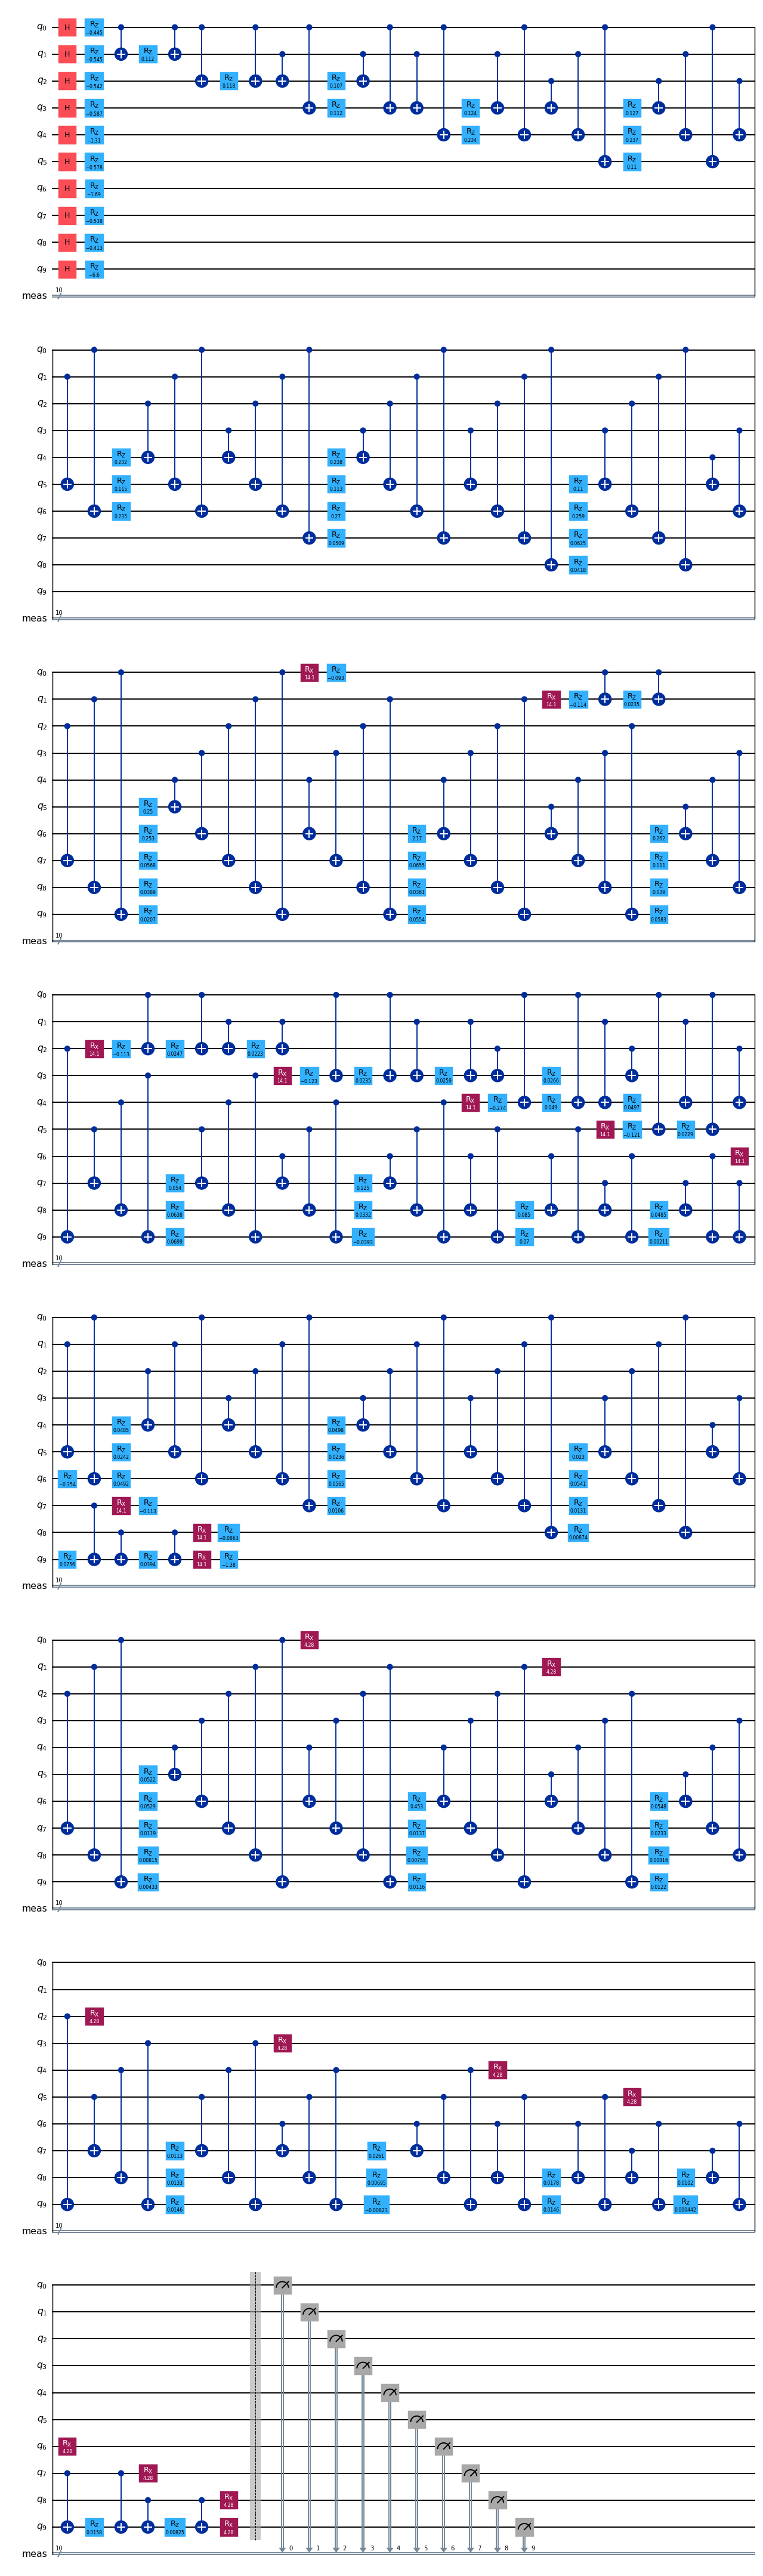

In [10]:
# --- 1) Draw the QAOA circuit with Qiskit's mpl drawer (rendered image) ---
# %matplotlib inline forces the image backend, so circuit.draw(output="mpl")
# renders as an actual diagram (no <Figure ...> text repr).
# Guide: https://quantum.cloud.ibm.com/docs/en/guides/construct-circuits
%matplotlib inline
import matplotlib.pyplot as plt
from qiskit import transpile
from IPython.display import display

# QAOA's ansatz with the optimal angles bound in: an H on every qubit (equal
# superposition), then `reps` repetitions of a cost layer (RZ / RZZ from our
# Hamiltonian) + a mixer layer (RX). Transpile to basic gates so the diagram
# shows the real gate structure instead of a high-level PauliEvolution block.
bound = qaoa.ansatz.assign_parameters(result.optimal_point)
circuit_to_draw = transpile(bound, basis_gates=["h", "rx", "rz", "cx"],
                            optimization_level=0)

print(f"QAOA circuit: {circuit_to_draw.num_qubits} qubits, "
      f"depth {circuit_to_draw.depth()}, "
      f"{qaoa.ansatz.num_parameters} parameters (bound in).")
print("Gate counts:", dict(circuit_to_draw.count_ops()))

# fold wraps the wide circuit into stacked rows; scale keeps the image readable.
fig = circuit_to_draw.draw(output="mpl", fold=26, scale=0.7)
display(fig)
plt.close(fig)  # prevent a duplicate auto-display at cell end

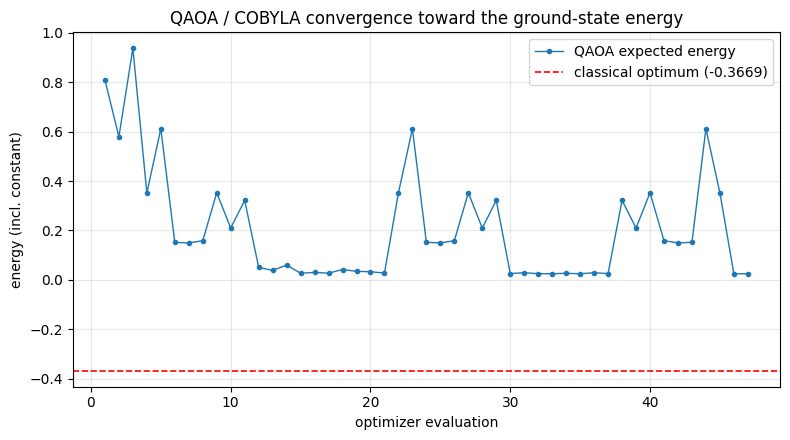

start energy 0.8085 -> final 0.0250  |  classical optimum -0.3669  |  47 evaluations


In [11]:
# --- 2) Energy-convergence graph -----------------------------------------
# %matplotlib inline forces the inline (image) backend, so this renders as a picture
# even if an earlier cell left matplotlib on a non-display backend in this kernel.
%matplotlib inline
import matplotlib.pyplot as plt

# Add CONST back so the y-axis matches the brute-force optimum's energy scale.
energies_with_const = [e + CONST for e in history["energies"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(history["evals"], energies_with_const, marker="o", ms=3, lw=1,
        label="QAOA expected energy")
ax.axhline(bf["energy"], color="red", ls="--", lw=1.2,
           label=f"classical optimum ({bf['energy']:.4f})")
ax.set_xlabel("optimizer evaluation")
ax.set_ylabel("energy (incl. constant)")
ax.set_title("QAOA / COBYLA convergence toward the ground-state energy")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"start energy {energies_with_const[0]:.4f} -> final {energies_with_const[-1]:.4f}"
      f"  |  classical optimum {bf['energy']:.4f}  |  {len(energies_with_const)} evaluations")

In [ ]:
# --- 3) Histogram of sampled bitstrings ----------------------------------
%matplotlib inline
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

# Relabel qiskit's little-endian keys into our big-endian "x_0 first" convention
# so the bars match selected_candidates.csv / the brute-force CSV.
big_endian_dist = {
    "".join(str(b) for b in little_endian_to_x(bs_le, N)): p
    for bs_le, p in dist.items()
}
# Keep the most probable handful so the chart stays readable -- but the winner
# (chosen by LOWEST ENERGY, not by frequency) can easily be a rare sample, so it
# is not guaranteed to be among the most-frequent bars. Force it in explicitly
# rather than hoping it lands there, so the "winner highlighted" claim is always true.
top_items = sorted(big_endian_dist.items(), key=lambda kv: kv[1], reverse=True)[:11]
top = dict(top_items)
winner_in_top_11_by_frequency = x_string in top
if not winner_in_top_11_by_frequency:
    top[x_string] = big_endian_dist.get(x_string, 0.0)

fig = plot_histogram(
    top,
    figsize=(11, 5),
    title=f"QAOA sampled bitstrings (top {len(top)}) - winner {x_string} highlighted",
    sort="value_desc",
    bar_labels=False,
)
# Highlight the winning (lowest-energy) bitstring in red. Guaranteed to find a
# match now, since x_string was force-included above if it wasn't already present.
ax = fig.axes[0]
for label, patch in zip([t.get_text() for t in ax.get_xticklabels()], ax.patches):
    if label == x_string:
        patch.set_color("crimson")
plt.show()

if not winner_in_top_11_by_frequency:
    print(f"Note: winner {x_string} was NOT among the 11 most-frequently sampled "
          f"bitstrings (its own measured probability was only "
          f"{big_endian_dist.get(x_string, 0.0):.4f}) -- it was added to the chart "
          f"explicitly so the highlighted bar is always the true answer.")

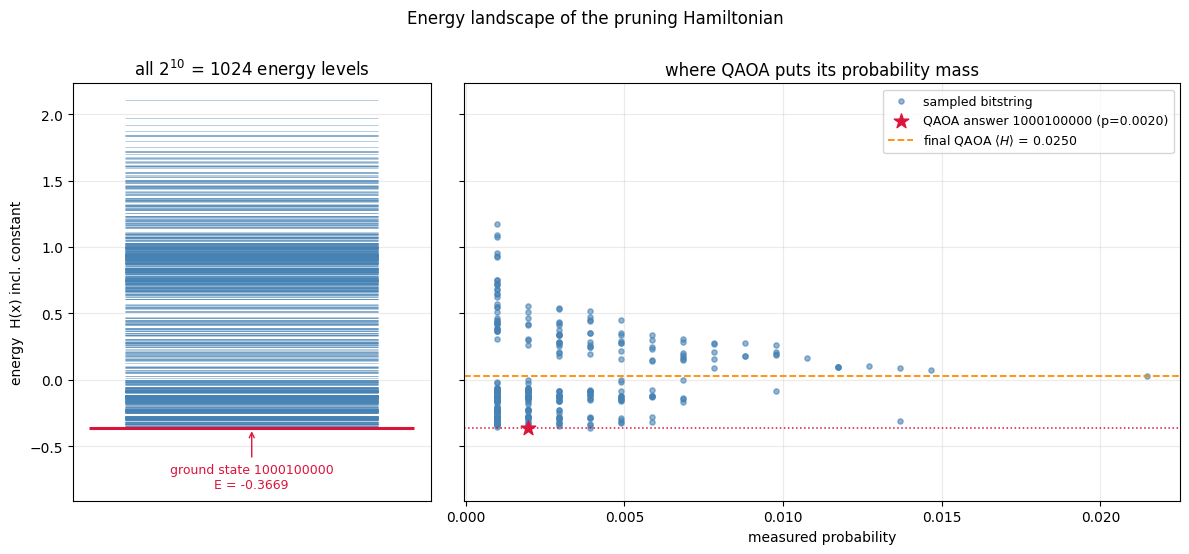

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

# --- 4) Energy levels of the pruning Hamiltonian --------------------------
# Left: the FULL exact spectrum -- ising_energy() evaluated on every one of the
# 2^N bitstrings (10 qubits -> 1024 levels), ground state highlighted. Right:
# every bitstring QAOA actually sampled, placed by measured probability vs its
# energy. A working QAOA pushes probability mass toward the bottom of the
# spectrum, and its final expectation <H> sits well below the bulk of levels.
all_energies = np.array([
    ising_energy([int(c) for c in format(k, f"0{N}b")]) for k in range(2 ** N)
])
e_ground = float(all_energies.min())
qaoa_expectation = float(result.optimal_value) + CONST

fig, (ax_lvl, ax_prob) = plt.subplots(
    1, 2, figsize=(12, 5.5), width_ratios=[1, 2], sharey=True)

ax_lvl.hlines(all_energies, 0.15, 0.85, color="steelblue", lw=0.7, alpha=0.4)
ax_lvl.hlines(e_ground, 0.05, 0.95, color="crimson", lw=2.2)
span = float(all_energies.max()) - e_ground
ax_lvl.set_ylim(e_ground - 0.22 * span, float(all_energies.max()) + 0.05 * span)
ax_lvl.annotate(f"ground state {bf['bitstring']}\nE = {e_ground:.4f}",
                xy=(0.5, e_ground), xytext=(0.5, e_ground - 0.18 * span),
                ha="center", fontsize=9, color="crimson",
                arrowprops=dict(arrowstyle="->", color="crimson", lw=1))
ax_lvl.set_xticks([])
ax_lvl.set_ylabel("energy  H(x) incl. constant")
ax_lvl.set_title(f"all $2^{{{N}}}$ = {2 ** N} energy levels")

sampled_e = [ising_energy(little_endian_to_x(bs_le, N)) for bs_le in dist]
sampled_p = list(dist.values())
ax_prob.scatter(sampled_p, sampled_e, s=14, color="steelblue", alpha=0.6,
                label="sampled bitstring")
ax_prob.scatter([mp_prob], [qaoa_energy], s=120, color="crimson", marker="*",
                zorder=3, label=f"QAOA answer {x_string} (p={mp_prob:.4f})")
ax_prob.axhline(qaoa_expectation, color="darkorange", ls="--", lw=1.3,
                label=f"final QAOA $\\langle H\\rangle$ = {qaoa_expectation:.4f}")
ax_prob.axhline(e_ground, color="crimson", ls=":", lw=1.1)
ax_prob.set_xlabel("measured probability")
ax_prob.set_title("where QAOA puts its probability mass")
ax_prob.legend(fontsize=9)
for a in (ax_lvl, ax_prob):
    a.grid(alpha=0.25)
fig.suptitle("Energy landscape of the pruning Hamiltonian", y=1.0)
fig.tight_layout()
plt.show()

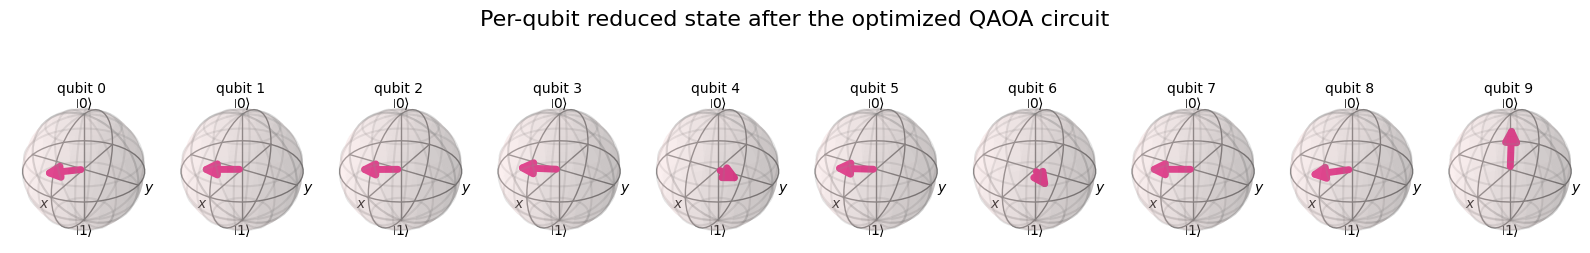

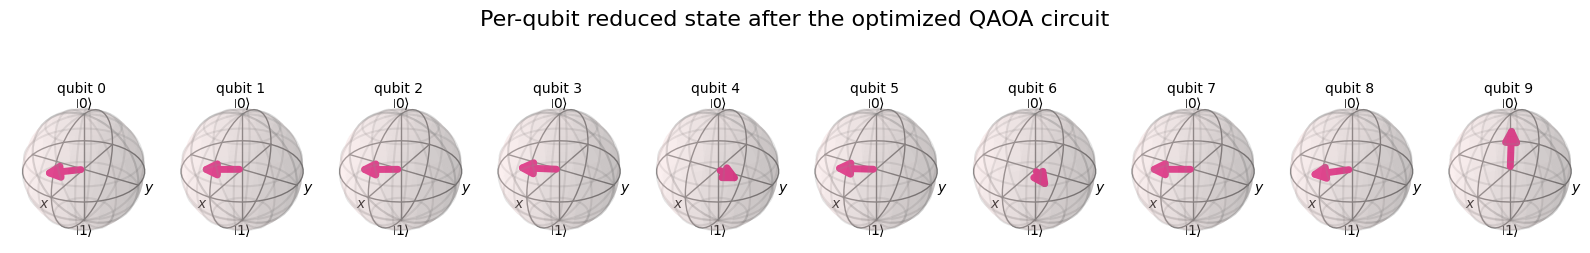

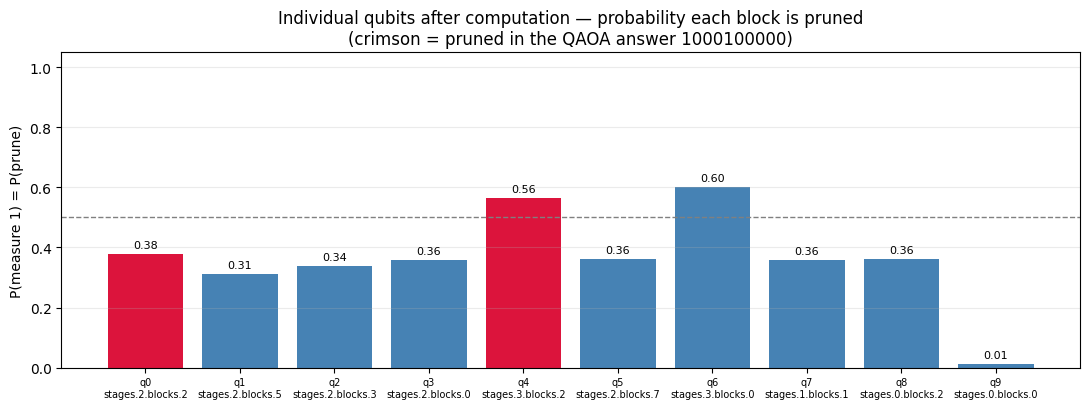

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

# --- 5) Individual qubits after the computation ----------------------------
# Two views of the final 10-qubit state:
#  * Bloch sphere of each qubit's REDUCED state, from the exact statevector of
#    the bound circuit (qiskit's plot_bloch_multivector). A long arrow means the
#    qubit has effectively decided on its own (up = keep |0>, down = prune |1>);
#    a short arrow near the centre means it is strongly entangled with the rest,
#    so its share of the answer lives in correlations, not in the marginal.
#  * Each qubit's measured P(1) = P(prune its block), marginalized from the
#    sampled distribution `dist`.
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display
from qiskit import transpile

# qaoa.ansatz may end in measurements; drop them to get the pre-measurement state,
# then decompose to basis gates so Statevector builds it cheaply (like the sampler).
_state_circ = qaoa.ansatz.assign_parameters(result.optimal_point).remove_final_measurements(inplace=False)
_state_circ = transpile(_state_circ, basis_gates=["h", "rx", "rz", "cx"], optimization_level=0)
final_state = Statevector(_state_circ)
display(plot_bloch_multivector(
    final_state, title="Per-qubit reduced state after the optimized QAOA circuit"))

p_prune = np.zeros(N)
for bs_le, p in dist.items():
    p_prune += p * np.array(little_endian_to_x(bs_le, N))

names = [c["candidate"] for c in candidates]  # already sorted by qubit_index
colors = ["crimson" if int(b) else "steelblue" for b in x_string]

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(range(N), p_prune, color=colors)
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.set_xticks(range(N))
ax.set_xticklabels([f"q{i}\n{names[i]}" for i in range(N)], fontsize=7)
ax.set_ylim(0, 1.05)
ax.set_ylabel("P(measure 1) = P(prune)")
ax.set_title("Individual qubits after computation — probability each block is pruned\n"
             f"(crimson = pruned in the QAOA answer {x_string})")
for i, v in enumerate(p_prune):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
ax.grid(alpha=0.25, axis="y")
fig.tight_layout()
plt.show()

## Step 5 - Prune the real model (genuine removal) and evaluate

Now we **act on the QAOA result**: take the blocks QAOA chose (`pruned`) and
**physically delete them** from the fine-tuned ConvNeXT, producing a genuinely
smaller model (fewer parameters, smaller on disk), then measure accuracy / loss /
F1 on the Canadian-streetview test set.

Removal is shape-safe: every block inside a ConvNeXT *stage* preserves channel and
spatial dimensions (that is exactly why the Step-2 *bypass* simulation was valid),
so dropping blocks from a stage's `nn.Sequential` leaves the tensor path intact.
Stage `downsample` layers are never touched.

> **Why this matters:** Step 2 measured each block's damage *individually*, and the
> QUBO simply *summed* those penalties (no interaction term). This cell is the
> empirical check: **predicted** drop (sum of individual sensitivities) vs the
> **actual** drop when all chosen blocks are removed **together**, plus the **real**
> parameter reduction vs the QUBO's estimate.
>
> Requires the ML stack: `pip install torch torchvision timm huggingface_hub datasets scikit-learn`.
> The model (~110 MB) and a test-set subset are downloaded from the Hugging Face Hub on first run.

In [15]:
# --- ML helpers (same preprocessing / eval / bypass logic as Step 2) ------
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2
from sklearn.metrics import accuracy_score, f1_score
import timm
from datasets import load_dataset
from huggingface_hub import hf_hub_download


def resize_and_pad(img: Image.Image, target_size=(320, 320)) -> Image.Image:
    """ConvNeXT preprocessing: thumbnail + center-pad onto a black canvas."""
    img = img.copy()
    img.thumbnail(target_size, Image.Resampling.LANCZOS)
    canvas = Image.new("RGB", target_size, (0, 0, 0))
    canvas.paste(img, ((target_size[0] - img.size[0]) // 2,
                       (target_size[1] - img.size[1]) // 2))
    return canvas


CONVNEXT_TRANSFORM = v2.Compose([
    v2.Lambda(lambda img: resize_and_pad(img)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class StreetViewSubset(Dataset):
    """Small in-memory subset of the HF dataset for a fast evaluation."""
    def __init__(self, hf_dataset, transform):
        self.data = list(hf_dataset)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        img = row["image"]
        if not isinstance(img, Image.Image):
            img = Image.open(img)
        return self.transform(img.convert("RGB")), int(row["label"])


def load_convnext(device: torch.device) -> nn.Module:
    """Load the fine-tuned ConvNeXT-tiny checkpoint from the HF Hub."""
    path = hf_hub_download(
        repo_id="canada-guesser/canadian_streetview_cities_models",
        filename="cnn_model/convnext_tiny_set_3_final.bin",
    )
    model = timm.create_model("convnext_tiny", pretrained=False, num_classes=15)
    ckpt = torch.load(path, map_location=device, weights_only=False)
    state = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
    model.load_state_dict(state)
    return model.to(device).eval()


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> Dict[str, float]:
    """Mean cross-entropy loss, accuracy and macro-F1 over the loader."""
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")
    total_loss, total = 0.0, 0
    preds, labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total_loss += float(criterion(logits, yb).item())
        total += int(yb.numel())
        preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
        labels.extend(yb.cpu().tolist())
    return {
        "loss": total_loss / max(total, 1),
        "accuracy": float(accuracy_score(labels, preds)),
        "macro_f1": float(f1_score(labels, preds, average="macro", zero_division=0)),
        "n_samples": total,
    }


class CandidateWrapper(nn.Module):
    """Wraps a block so it can be bypassed (forward(x) -> x) to simulate pruning."""
    def __init__(self, module: nn.Module):
        super().__init__()
        self.module = module
        self.bypass = False

    def forward(self, x, *args, **kwargs):
        return x if self.bypass else self.module(x, *args, **kwargs)


def get_module(model: nn.Module, name: str) -> nn.Module:
    """Resolve a dotted module path like 'stages.3.blocks.2'."""
    mod = model
    for part in name.split("."):
        mod = mod[int(part)] if part.isdigit() else getattr(mod, part)
    return mod


def replace_module(model: nn.Module, name: str, new_module: nn.Module) -> None:
    """Replace the submodule at a dotted path with new_module (in place)."""
    parts = name.split(".")
    parent = model
    for part in parts[:-1]:
        parent = parent[int(part)] if part.isdigit() else getattr(parent, part)
    key = parts[-1]
    if key.isdigit():
        parent[int(key)] = new_module
    else:
        setattr(parent, key, new_module)

print("ML helpers ready.")

ML helpers ready.


In [16]:
# --- Load the model + test subset, then measure the baseline -------------
# MAX_SAMPLES trades speed vs. statistical stability. Step 2 used 600; raise this
# (or use the full split) for final numbers. On CPU each evaluation is a few minutes.
MAX_SAMPLES = 600
BATCH_SIZE = 16

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch device: {torch_device}")

print("Loading fine-tuned ConvNeXT-tiny ...")
prune_model = load_convnext(torch_device)

print(f"Loading test[:{MAX_SAMPLES}] subset ...")
test_ds = load_dataset("canada-guesser/Canadian-streetview-cities", split=f"test[:{MAX_SAMPLES}]")
test_loader = DataLoader(
    StreetViewSubset(test_ds, CONVNEXT_TRANSFORM),
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)

print("Evaluating baseline (unpruned) model ...")
baseline_metrics = evaluate(prune_model, test_loader, torch_device)
print(f"Baseline: loss={baseline_metrics['loss']:.6f}  "
      f"acc={baseline_metrics['accuracy']:.4f}  "
      f"f1={baseline_metrics['macro_f1']:.4f}  n={baseline_metrics['n_samples']}")

Torch device: cpu
Loading fine-tuned ConvNeXT-tiny ...


Loading test[:600] subset ...


Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating baseline (unpruned) model ...


Baseline: loss=0.088637  acc=0.9917  f1=0.9911  n=600


In [17]:
# --- Genuinely remove the QAOA-selected blocks, then re-evaluate ----------
# Unlike Step 2's bypass, this PHYSICALLY deletes the chosen blocks from each
# stage's nn.Sequential, so `prune_model` becomes a smaller network we can save.
import re
from collections import defaultdict

prune_targets = list(pruned)
print(f"QAOA chose to prune {len(prune_targets)} block(s): {prune_targets}\n")


def structurally_remove_blocks(model: nn.Module, block_names: List[str]) -> nn.Module:
    """Physically delete named blocks (stages.S.blocks.B) from each stage's Sequential.

    Shape-safe: blocks within a ConvNeXT stage preserve channel/spatial dims, which
    is precisely why the Step-2 bypass was valid. Rebuilding each stage's `blocks`
    from the surviving modules makes reindexing automatic. Downsample layers are
    left untouched. convnext_tiny depths are (3, 3, 9, 3), so stage 2 has blocks
    0-8 and stages 0/1/3 have blocks 0-2 -- all current candidates are valid.
    """
    to_remove = defaultdict(set)
    for name in block_names:
        m = re.match(r"stages\.(\d+)\.blocks\.(\d+)$", name.strip())
        if not m:
            raise ValueError(f"Unexpected block name (expected stages.S.blocks.B): {name}")
        to_remove[int(m.group(1))].add(int(m.group(2)))

    for stage_idx, idxs in sorted(to_remove.items()):
        blocks = model.stages[stage_idx].blocks
        kept = [blk for i, blk in enumerate(blocks) if i not in idxs]
        model.stages[stage_idx].blocks = nn.Sequential(*kept)
        print(f"  stage {stage_idx}: removed blocks {sorted(idxs)} "
              f"({len(blocks)} -> {len(kept)} blocks)")
    return model


def count_params(model: nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters()))


# Count BEFORE removal (prune_model still full here; baseline_metrics already measured).
baseline_params = count_params(prune_model)

# Genuine structural removal -- prune_model is now physically smaller.
structurally_remove_blocks(prune_model, prune_targets)
pruned_params = count_params(prune_model)
removed_params = baseline_params - pruned_params
reduction_fraction = removed_params / baseline_params if baseline_params else 0.0

print("\nEvaluating genuinely-pruned (smaller) model ...")
# Timed so quantum_vs_classical_comparison.ipynb can compare eval cost fairly.
_eval_t0 = time.perf_counter()
pruned_metrics = evaluate(prune_model, test_loader, torch_device)
pruned_eval_seconds = time.perf_counter() - _eval_t0

# Actual, measured impact of removing all chosen blocks at once.
actual_loss_inc = pruned_metrics["loss"] - baseline_metrics["loss"]
actual_acc_drop = baseline_metrics["accuracy"] - pruned_metrics["accuracy"]
actual_f1_drop = baseline_metrics["macro_f1"] - pruned_metrics["macro_f1"]

# Predicted impact = sum of INDIVIDUAL per-block sensitivities from Step 2
# (exactly what the linear part of the QUBO assumed: no interaction between blocks).
predicted_loss_inc, predicted_acc_drop = 0.0, 0.0
sens_path = Path("cost_loss_table.csv")
if sens_path.exists():
    with sens_path.open(newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            if row.get("candidate") in prune_targets:
                predicted_loss_inc += float(row.get("loss_increase_raw", 0.0) or 0.0)
                predicted_acc_drop += float(row.get("accuracy_drop_raw", 0.0) or 0.0)

# The QUBO's own estimate of params removed (sum over candidate table) vs the REAL count.
estimated_params_removed = sum(
    int(c["params"]) for c in candidates if c["candidate"] in prune_targets
)

print("\n" + "=" * 64)
print("REAL-MODEL PRUNING RESULT (genuine structural removal)")
print("=" * 64)
print(f"{'metric':<16}{'baseline':>12}{'pruned':>12}{'change':>12}")
print("-" * 64)
print(f"{'loss':<16}{baseline_metrics['loss']:>12.4f}{pruned_metrics['loss']:>12.4f}{actual_loss_inc:>+12.4f}")
print(f"{'accuracy':<16}{baseline_metrics['accuracy']:>12.4f}{pruned_metrics['accuracy']:>12.4f}{-actual_acc_drop:>+12.4f}")
print(f"{'macro_f1':<16}{baseline_metrics['macro_f1']:>12.4f}{pruned_metrics['macro_f1']:>12.4f}{-actual_f1_drop:>+12.4f}")
print("-" * 64)
print(f"Params : baseline={baseline_params:,}  pruned={pruned_params:,}  "
      f"removed={removed_params:,}  ({reduction_fraction:.2%})")
print(f"QUBO-estimated params removed: {estimated_params_removed:,}  (real: {removed_params:,})")
print(f"\nPredicted vs actual (tests the QUBO's no-interaction assumption):")
print(f"  loss increase : predicted(sum of singles)={predicted_loss_inc:.4f}   actual(together)={actual_loss_inc:.4f}")
print(f"  accuracy drop : predicted(sum of singles)={predicted_acc_drop:.4f}   actual(together)={actual_acc_drop:.4f}")
if actual_loss_inc > predicted_loss_inc * 1.5 and predicted_loss_inc > 0:
    print("  -> Actual damage notably exceeds the sum: blocks interact. Consider")
    print("     leaning on the QUBO's pairwise topology terms.")
else:
    print("  -> Actual damage is close to the sum: the linear QUBO assumption holds well.")

# Persist alongside the QAOA result.
with (INDIR / "pruning_eval.json").open("w", encoding="utf-8") as f:
    json.dump({
        "pruned_blocks": prune_targets,
        "removal_method": "structural (blocks physically deleted)",
        "params_baseline": baseline_params,
        "params_pruned": pruned_params,
        "params_removed": removed_params,
        "param_reduction_fraction": reduction_fraction,
        "estimated_params_removed_from_qubo": estimated_params_removed,
        "max_samples": MAX_SAMPLES,
        "eval_seconds": pruned_eval_seconds,
        "baseline": baseline_metrics,
        "pruned": pruned_metrics,
        "actual": {"loss_increase": actual_loss_inc,
                   "accuracy_drop": actual_acc_drop,
                   "f1_drop": actual_f1_drop},
        "predicted_from_step2": {"loss_increase": predicted_loss_inc,
                                 "accuracy_drop": predicted_acc_drop},
    }, f, indent=2)
print(f"\nSaved real-model evaluation to: {INDIR / 'pruning_eval.json'}")

QAOA chose to prune 2 block(s): ['stages.2.blocks.2', 'stages.3.blocks.2']

  stage 2: removed blocks [2] (9 -> 8 blocks)
  stage 3: removed blocks [2] (3 -> 2 blocks)

Evaluating genuinely-pruned (smaller) model ...



REAL-MODEL PRUNING RESULT (genuine structural removal)
metric              baseline      pruned      change
----------------------------------------------------------------
loss                  0.0886      0.1953     +0.1066
accuracy              0.9917      0.9600     -0.0317
macro_f1              0.9911      0.9574     -0.0337
----------------------------------------------------------------
Params : baseline=27,831,663  pruned=21,866,607  removed=5,965,056  (21.43%)
QUBO-estimated params removed: 5,965,056  (real: 5,965,056)

Predicted vs actual (tests the QUBO's no-interaction assumption):
  loss increase : predicted(sum of singles)=0.0875   actual(together)=0.1066
  accuracy drop : predicted(sum of singles)=0.0200   actual(together)=0.0317
  -> Actual damage is close to the sum: the linear QUBO assumption holds well.

Saved real-model evaluation to: qubo_outputs\pruning_eval.json


## Step 6 - Save the pruned model for Hugging Face

Stage three files into `pruned_model_hf/`:

- `pytorch_model.bin` - the **smaller** model's `state_dict` (genuinely fewer params).
- `pruning_config.json` - provenance + the exact **reconstruction recipe** (which
  blocks were removed, the QAOA result, params, metrics).
- `README.md` - a model card with runnable reload code.

To reload later: build `convnext_tiny`, apply the **same** block removal, then
`load_state_dict` - the config lists exactly which blocks to drop.

In [18]:
# --- Stage the pruned model + metadata + model card ----------------------
import shutil

CLASS_NAMES = [
    "Calgary", "Charlottetown", "Edmonton", "Halifax", "Hamilton",
    "Kitchener-Waterloo", "Montreal", "Ottawa-Gatineau", "Quebec City",
    "Saskatoon", "St Johns", "Toronto", "Vancouver", "Victoria", "Winnipeg",
]

HF_STAGING = Path("pruned_model_hf")
if HF_STAGING.exists():
    shutil.rmtree(HF_STAGING)
HF_STAGING.mkdir(parents=True, exist_ok=True)

# 1) weights of the genuinely-smaller model
torch.save(prune_model.state_dict(), HF_STAGING / "pytorch_model.bin")

# target compression from Step-3 metadata (if available)
target_compression = None
meta_path = INDIR / "qubo_metadata.json"
if meta_path.exists():
    with meta_path.open("r", encoding="utf-8") as f:
        target_compression = json.load(f).get("target_compression")

# 2) reconstruction recipe + provenance
pruning_config = {
    "base_model": {
        "arch": "convnext_tiny",
        "num_classes": 15,
        "source_repo": "canada-guesser/canadian_streetview_cities_models",
        "source_file": "cnn_model/convnext_tiny_set_3_final.bin",
    },
    "pruned_blocks": prune_targets,
    "removal_method": "structural",
    "qaoa": {
        "best_bitstring": x_string,
        "energy": qaoa_energy,
        "found_global_optimum": bool(found_optimum),
        "num_pruned_blocks": int(sum(x)),
        "reps": args.reps, "shots": args.shots, "seed": args.seed, "maxiter": args.maxiter,
        "solve_seconds": qaoa_solve_seconds,
    },
    "target_compression": target_compression,
    "params": {
        "baseline": baseline_params,
        "pruned": pruned_params,
        "removed": removed_params,
        "reduction_fraction": reduction_fraction,
    },
    "metrics": {"baseline": baseline_metrics, "pruned": pruned_metrics},
    "class_names": CLASS_NAMES,
}
with (HF_STAGING / "pruning_config.json").open("w", encoding="utf-8") as f:
    json.dump(pruning_config, f, indent=2)

# 3) model card (README.md). Built line-by-line so the reload recipe is embedded verbatim.
reload_lines = [
    "REPO_ID = \"your-username/convnext-tiny-quantum-pruned\"  # <-- your repo",
    "import re, json, torch",
    "import torch.nn as nn",
    "import timm",
    "from collections import defaultdict",
    "from huggingface_hub import hf_hub_download",
    "",
    "cfg = json.load(open(hf_hub_download(REPO_ID, 'pruning_config.json')))",
    "model = timm.create_model('convnext_tiny', pretrained=False, num_classes=15)",
    "",
    "to_remove = defaultdict(set)",
    "for name in cfg['pruned_blocks']:",
    "    m = re.match(r'stages\\.(\\d+)\\.blocks\\.(\\d+)$', name)",
    "    to_remove[int(m.group(1))].add(int(m.group(2)))",
    "for s, idxs in to_remove.items():",
    "    blocks = model.stages[s].blocks",
    "    model.stages[s].blocks = nn.Sequential(*[b for i, b in enumerate(blocks) if i not in idxs])",
    "",
    "sd = torch.load(hf_hub_download(REPO_ID, 'pytorch_model.bin'), map_location='cpu')",
    "model.load_state_dict(sd)",
    "model.eval()",
]
reload_block = "\n".join(reload_lines)

card_lines = [
    "---",
    "license: mit",
    "tags:",
    "- image-classification",
    "- pruning",
    "- quantum",
    "- qaoa",
    "- convnext",
    "---",
    "",
    "# ConvNeXT-tiny - quantum-QAOA structured pruning",
    "",
    f"A fine-tuned ConvNeXT-tiny (Canadian street-view city classifier, 15 classes) "
    f"with **{len(prune_targets)} transformer blocks structurally removed**. The blocks were "
    f"chosen by solving a QUBO/Ising model of the loss-vs-compression trade-off with "
    f"**QAOA** (`qiskit_algorithms.QAOA`).",
    "",
    "- **Base model:** `canada-guesser/canadian_streetview_cities_models` (`convnext_tiny`, 15 classes)",
    f"- **Removed blocks:** {prune_targets}",
    f"- **QAOA bitstring:** `{x_string}` (matched classical optimum: {bool(found_optimum)})",
    f"- **Target compression:** {target_compression}",
    "",
    "## Parameters",
    "",
    "| | params |",
    "|---|---|",
    f"| baseline | {baseline_params:,} |",
    f"| pruned | {pruned_params:,} |",
    f"| removed | {removed_params:,} ({reduction_fraction:.2%}) |",
    "",
    f"## Metrics (test[:{MAX_SAMPLES}])",
    "",
    "| metric | baseline | pruned |",
    "|---|---|---|",
    f"| accuracy | {baseline_metrics['accuracy']:.4f} | {pruned_metrics['accuracy']:.4f} |",
    f"| macro F1 | {baseline_metrics['macro_f1']:.4f} | {pruned_metrics['macro_f1']:.4f} |",
    f"| loss | {baseline_metrics['loss']:.4f} | {pruned_metrics['loss']:.4f} |",
    "",
    "## Reload",
    "",
    "```python",
    reload_block,
    "```",
    "",
]
with (HF_STAGING / "README.md").open("w", encoding="utf-8") as f:
    f.write("\n".join(card_lines))

print("Staged files:")
for p in sorted(HF_STAGING.iterdir()):
    print(f"  {p}  ({p.stat().st_size / 1e6:.2f} MB)")

Staged files:
  pruned_model_hf\pruning_config.json  (0.00 MB)
  pruned_model_hf\pytorch_model.bin  (87.53 MB)
  pruned_model_hf\README.md  (0.00 MB)


## Step 7 - Upload to Hugging Face

Set `HF_REPO_ID` to your repo (e.g. `yourname/convnext-tiny-quantum-pruned`) and run.

**Prerequisite:** a valid **write** token. If it is missing/expired this cell prints
login instructions and skips cleanly (so the notebook always runs end-to-end). To set one:

```
hf auth login --force      # or: huggingface-cli login
```

In [19]:
# --- Upload to Hugging Face (guarded) ------------------------------------
HF_REPO_ID = "<your-username>/convnext-tiny-quantum-pruned"  # <-- EDIT THIS
HF_PRIVATE = True
DO_UPLOAD = True

from huggingface_hub import HfApi, whoami


def _hf_identity():
    try:
        return True, whoami().get("name")
    except Exception as e:
        return False, str(e)


if not DO_UPLOAD:
    print("DO_UPLOAD is False -> skipping upload.")
elif "<your-username>" in HF_REPO_ID:
    print("Set HF_REPO_ID to your real repo id, e.g. 'yourname/convnext-tiny-quantum-pruned',")
    print("then re-run this cell.")
else:
    ok, who = _hf_identity()
    if not ok:
        print("Hugging Face token missing/invalid -> skipping upload.")
        print("Enable it by running in a terminal:")
        print("    hf auth login --force        (or: huggingface-cli login)")
        print("with a WRITE token, then re-run this cell.")
        print(f"(whoami error: {who})")
    else:
        print(f"Authenticated as: {who}")
        api = HfApi()
        api.create_repo(repo_id=HF_REPO_ID, repo_type="model",
                        private=HF_PRIVATE, exist_ok=True)
        api.upload_folder(folder_path=str(HF_STAGING), repo_id=HF_REPO_ID, repo_type="model")
        print(f"Uploaded pruned model to: https://huggingface.co/{HF_REPO_ID}")

Set HF_REPO_ID to your real repo id, e.g. 'yourname/convnext-tiny-quantum-pruned',
then re-run this cell.
